BERT
[np.float64(0.6569999999999999)]
RoBERTa
[np.float64(0.6159999999999999)]
HateBERT
[np.float64(0.7430000000000001), np.float64(0.5075000000000001)]
MetaHateBERT
[np.float64(0.689), np.float64(0.5775)]
LLaMA 3.1 8B
[np.float64(0.5124999999999998), np.float64(0.6345000000000001), np.float64(0.762)]
LLaMA 3.1 70B
[np.float64(0.6443750000000001), np.float64(0.6827272727272727), np.float64(0.7741666666666668)]
GPT-4.1
[np.float64(0.6564285714285715), np.float64(0.7384615384615384)]
Perspective API
[np.float64(0.58)]


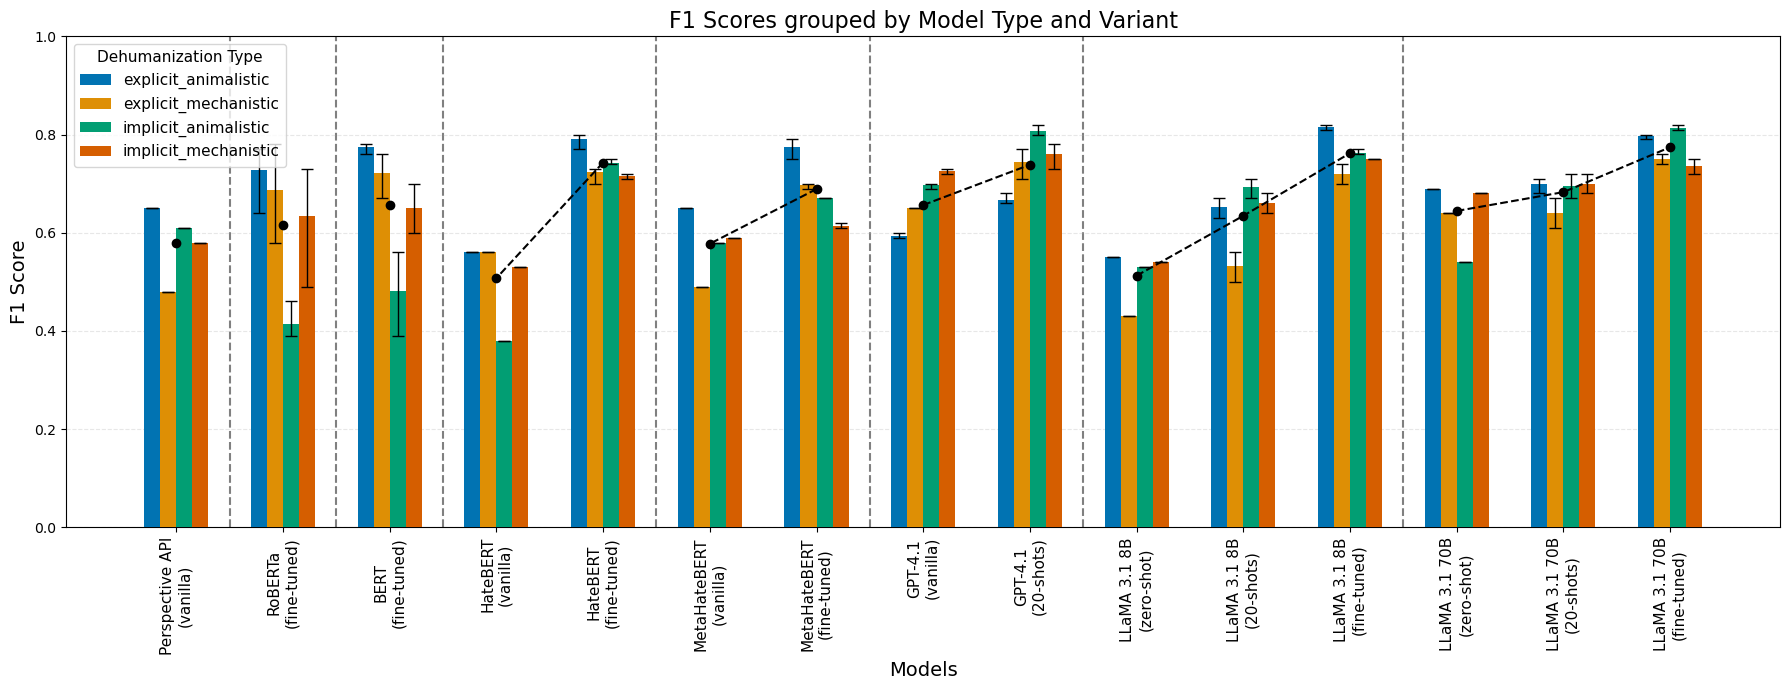

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# CSV einlesen
df = pd.read_csv("../experiments/evaluation/eval_summary.csv")

# Gruppierung und Variantenlogik anpassen
def extract_group_variant(model):
    if model.startswith("Llama-3.1-8B-Instruct"):
        variant = model.replace("Llama-3.1-8B-Instruct_", "").replace("fine_tuned", "fine-tuned").replace("20_shots", "20-shots").replace("zero_shot", "zero-shot")
        return "LLaMA 3.1 8B", variant
    elif model.startswith("Llama-3.1-70B-Instruct"):
        variant = model.replace("Llama-3.1-70B-Instruct_", "").replace("fine_tuned", "fine-tuned").replace("20_shots", "20-shots").replace("zero_shot", "zero-shot")
        return "LLaMA 3.1 70B", variant
    elif model.startswith("gpt4_"):
        return "GPT-4.1", model.replace("gpt4_", "").replace("20_shots", "20-shots")
    elif model == "gpt4":
        return "GPT-4.1", "vanilla"
    elif model.startswith("perspective_api"):
        return "Perspective API", "vanilla"
    elif model.endswith("_vanilla"):
        base = model.replace("_vanilla", "")
        return base if base != "bert" else "BERT", "vanilla"
    elif model in ["RoBERTa", "BERT", "HateBERT", "MetaHateBERT"]:
        return model, "fine-tuned"
    else:
        return model, "unknown"

# Spalten ergänzen
df['Model Group'], df['Variant'] = zip(*df['model'].map(extract_group_variant))
df['x_label'] = df['Model Group'] + '\n(' + df['Variant'] + ')'

# Sortierlogik
capability_order = [
    "Perspective API",
    "RoBERTa",
    "BERT",
    "HateBERT",
    "MetaHateBERT",
    "GPT-4.1",
    "LLaMA 3.1 8B",
    "LLaMA 3.1 70B"
]

variant_order = ["vanilla", "zero-shot", "20-shots", "fine-tuned"]

df['Capability Rank'] = df['Model Group'].apply(lambda x: capability_order.index(x) if x in capability_order else len(capability_order))
df['Variant Rank'] = df['Variant'].apply(lambda x: variant_order.index(x) if x in variant_order else len(variant_order))

# Aggregation
agg_df = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_type']).agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

# Sortierung der Achsenlabels
df['x_label'] = pd.Categorical(df['x_label'], categories=sorted(df['x_label'].unique(), key=lambda x: (
    capability_order.index(x.split('\n')[0]) if x.split('\n')[0] in capability_order else len(capability_order),
    variant_order.index(x.split('\n')[1].replace("(", "").replace(")", "")) if x.split('\n')[1].replace("(", "").replace(")", "") in variant_order else len(variant_order)
)), ordered=True)

agg_df['x_label'] = pd.Categorical(agg_df['x_label'], categories=df['x_label'].cat.categories, ordered=True)
agg_df = agg_df.sort_values('x_label')

# Farbpalette nach gewünschter Reihenfolge
category_order = [
    "explicit_animalistic",
    "explicit_mechanistic",
    "implicit_animalistic",
    "implicit_mechanistic"
]
palette = sns.color_palette("colorblind", len(category_order))
category_colors = dict(zip(category_order, palette))

# Positionen vorbereiten
unique_labels = list(agg_df['x_label'].cat.categories)
x_pos = np.arange(len(unique_labels))
width = 0.15

# Plot erstellen
fig, ax = plt.subplots(figsize=(18, 7))

# Balken + Whisker
for idx, cat in enumerate(category_order):
    subset = agg_df[agg_df['dehum_type'] == cat]
    indices = [unique_labels.index(lbl) for lbl in subset['x_label']]
    offsets = [i + (idx - len(category_order)/2)*width + width/2 for i in indices]
    means = subset['mean'].values
    #print(means)
    yerr = [means - subset['min'].values, subset['max'].values - means]
    ax.bar(offsets, means, width=width, color=category_colors[cat], label=cat, zorder=3)
    ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)

# Vertikale Trennlinien zwischen Modellgruppen
group_boundaries = []
prev_group = None
for i, label in enumerate(unique_labels):
    group = label.split('\n')[0]
    if prev_group is not None and group != prev_group:
        group_boundaries.append(i - 0.5)
    prev_group = group

for boundary in group_boundaries:
    ax.axvline(boundary, color='grey', linestyle='--', zorder=1)

# Mittelwert-Linien pro Modellgruppe
for group in df['Model Group'].unique():
    group_df = df[df['Model Group'] == group]
    variants = group_df['x_label'].unique()
    if len(variants) == 0:
        continue
    indices = [unique_labels.index(lbl) for lbl in variants]
    means = [df[df['x_label'] == lbl]['f1'].mean() for lbl in variants]
    print(group)
    print(means)
    ax.plot(indices, means, linestyle='--', color='black', marker='o', zorder=5)

# Achsenbeschriftung und Layout
ax.set_xticks(range(len(unique_labels)))
ax.set_xticklabels(unique_labels, rotation=90, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=14)
ax.set_xlabel("Models", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title("F1 Scores grouped by Model Type and Variant", fontsize=16)
ax.legend(title="Dehumanization Type", fontsize=11, title_fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
#plt.savefig("f1_scores_grouped_fixed.png", dpi=300, transparent=True)
plt.show()

In [10]:
## mean model increase
df.groupby('model').agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()


,model,mean,min,max
0,BERT,0.657000,0.39,0.78
1,HateBERT,0.743000,0.70,0.80
2,HateBERT_vanilla,0.507500,0.38,0.56
3,Llama-3.1-70B-Instruct_20_shots,0.682727,0.61,0.72
4,Llama-3.1-70B-Instruct_fine_tuned,0.774167,0.72,0.82
5,Llama-3.1-70B-Instruct_zero_shot,0.644375,0.54,0.69
6,Llama-3.1-8B-Instruct_20_shots,0.634500,0.50,0.71
7,Llama-3.1-8B-Instruct_fine_tuned,0.762000,0.70,0.82
8,Llama-3.1-8B-Instruct_zero_shot,0.512500,0.43,0.55
9,MetaHateBERT,0.689000,0.61,0.79


In [11]:
## 8b english
old = 0.51
new = 0.76
first = (new - old) / old * 100

old = 0.64
new = 0.77
second = (new - old) / old * 100


## 8b german
old = 0.307
new = 0.753
third = (new - old) / old * 100

old = 0.51
new = 0.75
fourth = (new - old) / old * 100


##average first and second
(first + second + third + fourth) / 4


65.4169510841796

In [12]:
old = 0.51
new = 0.634
first = (new - old) / old * 100

old = 0.64
new = 0.68
second = (new - old) / old * 100

##average first and second
(first + second) / 2

15.281862745098042

In [13]:
old = 0.51
new = 0.76
(new - old) / old * 100

49.01960784313725

/var/folders/8l/cjyv75b11sl8w9_pt4rvl4v40000gn/T/ipykernel_45642/989581812.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_anim = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_animMech']).agg(


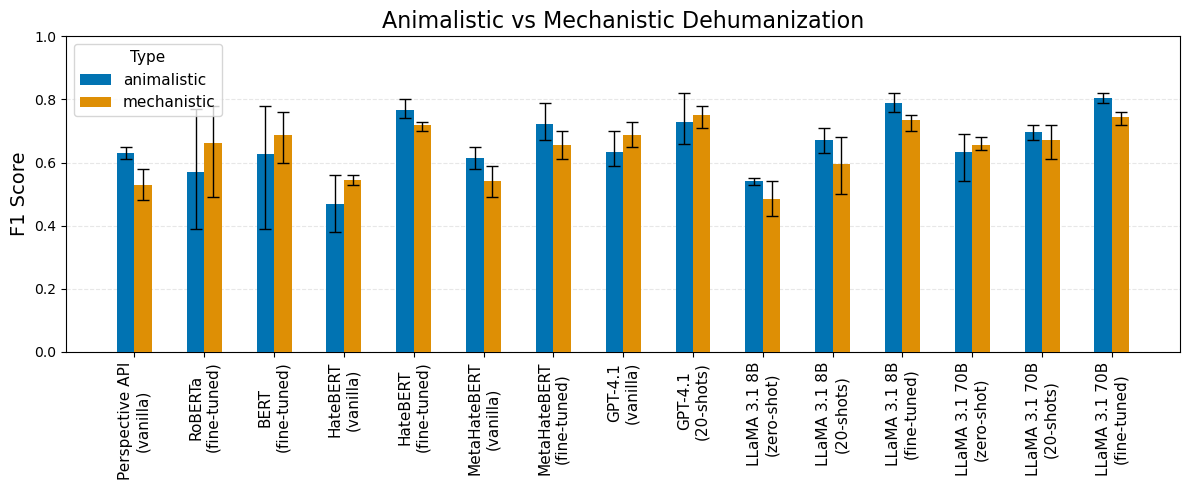

In [14]:
# ===============================
# 1) ANIMALISTIC vs MECHANISTIC
# ===============================

df['dehum_group_animMech'] = df['dehum_type'].map({
    'explicit_animalistic': 'animalistic',
    'implicit_animalistic': 'animalistic',
    'explicit_mechanistic': 'mechanistic',
    'implicit_mechanistic': 'mechanistic'
})

agg_anim = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_animMech']).agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

category_order_anim = ["animalistic", "mechanistic"]
palette_anim = sns.color_palette("colorblind", len(category_order_anim))
category_colors_anim = dict(zip(category_order_anim, palette_anim))

fig, ax = plt.subplots(figsize=(12, 5))
unique_labels = list(df['x_label'].cat.categories)
x_pos = np.arange(len(unique_labels))
width = 0.25

for idx, cat in enumerate(category_order_anim):
    subset = agg_anim[agg_anim['dehum_group_animMech'] == cat]
    indices = [unique_labels.index(lbl) for lbl in subset['x_label']]
    offsets = [i + (idx - len(category_order_anim)/2)*width + width/2 for i in indices]
    means = subset['mean'].values
    #print(means)
    yerr = [means - subset['min'].values, subset['max'].values - means]

    ax.bar(offsets, means, width=width, color=category_colors_anim[cat], label=cat, zorder=3)
    ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)

ax.set_xticks(range(len(unique_labels)))
ax.set_xticklabels(unique_labels, rotation=90, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=14)
#ax.set_xlabel("Models", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title("Animalistic vs Mechanistic Dehumanization", fontsize=16)
ax.legend(title="Type", fontsize=11, title_fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
#plt.savefig("f1_anim_vs_mech.pdf", dpi=300, transparent=True)
plt.show()

In [15]:
## mean model increase
df.groupby('Variant').agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

,Variant,mean,min,max
0,20-shots,0.677273,0.50,0.82
1,fine-tuned,0.702054,0.39,0.82
2,vanilla,0.609615,0.38,0.73
3,zero-shot,0.571111,0.43,0.69


/var/folders/8l/cjyv75b11sl8w9_pt4rvl4v40000gn/T/ipykernel_45642/2660497923.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_expimp = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_expImp']).agg(


(0.00392156862745098, 0.45098039215686275, 0.6980392156862745)
(0.8705882352941177, 0.5607843137254902, 0.0196078431372549)


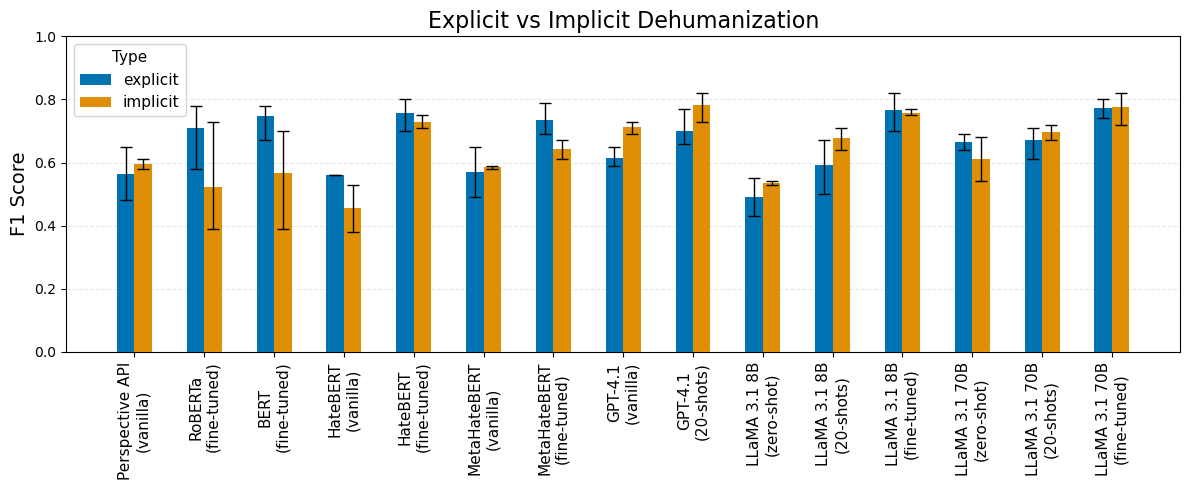

In [16]:
# ===============================
# 2) EXPLICIT vs IMPLICIT
# ===============================

df['dehum_group_expImp'] = df['dehum_type'].map({
    'explicit_animalistic': 'explicit',
    'explicit_mechanistic': 'explicit',
    'implicit_animalistic': 'implicit',
    'implicit_mechanistic': 'implicit'
})

agg_expimp = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_expImp']).agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

category_order_expimp = ["explicit", "implicit"]
palette_expimp = sns.color_palette("colorblind", len(category_order_expimp))
category_colors_expimp = dict(zip(category_order_expimp, palette_expimp))

fig, ax = plt.subplots(figsize=(12, 5))
unique_labels = list(df['x_label'].cat.categories)
x_pos = np.arange(len(unique_labels))
width = 0.25

for idx, cat in enumerate(category_order_expimp):
    subset = agg_expimp[agg_expimp['dehum_group_expImp'] == cat]
    
    indices = [unique_labels.index(lbl) for lbl in subset['x_label']]
    
    offsets = [i + (idx - len(category_order_expimp)/2)*width + width/2 for i in indices]
    means = subset['mean'].values
    print(category_colors_expimp[cat])
    yerr = [means - subset['min'].values, subset['max'].values - means]

    ax.bar(offsets, means, width=width, color=category_colors_expimp[cat], label=cat, zorder=3)
    ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)

ax.set_xticks(range(len(unique_labels)))
ax.set_xticklabels(unique_labels, rotation=90, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=14)
#ax.set_xlabel("Models", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title("Explicit vs Implicit Dehumanization", fontsize=16)
ax.legend(title="Type", fontsize=11, title_fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
#plt.savefig("f1_explicit_vs_implicit.pdf", dpi=300, transparent=True)
plt.show()

In [17]:
## hate BERT performance increase implicit
old = agg_expimp[
    (agg_expimp['x_label'] == 'HateBERT\n(vanilla)') &
    (agg_expimp['Model Group'] == 'HateBERT') &
    (agg_expimp['Variant'] == 'vanilla') &
    (agg_expimp['dehum_group_expImp'] == 'implicit')]["mean"].tolist()[0]

new = agg_expimp[
    (agg_expimp['x_label'] == 'HateBERT\n(fine-tuned)') &
    (agg_expimp['Model Group'] == 'HateBERT') &
    (agg_expimp['Variant'] == 'fine-tuned') &
    (agg_expimp['dehum_group_expImp'] == 'implicit')]["mean"].tolist()[0]

(new - old) / old * 100

60.219780219780205

In [18]:
## hate MetaBERT performance increase implicit
old = agg_expimp[
    (agg_expimp['x_label'] == 'MetaHateBERT\n(vanilla)') &
    (agg_expimp['Model Group'] == 'MetaHateBERT') &
    (agg_expimp['Variant'] == 'vanilla') &
    (agg_expimp['dehum_group_expImp'] == 'implicit')]["mean"].tolist()[0]

new = agg_expimp[
    (agg_expimp['x_label'] == 'MetaHateBERT\n(fine-tuned)') &
    (agg_expimp['Model Group'] == 'MetaHateBERT') &
    (agg_expimp['Variant'] == 'fine-tuned') &
    (agg_expimp['dehum_group_expImp'] == 'implicit')]["mean"].tolist()[0]

(new - old) / old * 100

9.743589743589753

In [19]:
## hate BERT performance increase explicit
old = agg_expimp[
    (agg_expimp['x_label'] == 'MetaHateBERT\n(vanilla)') &
    (agg_expimp['Model Group'] == 'MetaHateBERT') &
    (agg_expimp['Variant'] == 'vanilla') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

new = agg_expimp[
    (agg_expimp['x_label'] == 'MetaHateBERT\n(fine-tuned)') &
    (agg_expimp['Model Group'] == 'MetaHateBERT') &
    (agg_expimp['Variant'] == 'fine-tuned') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

(new - old) / old * 100

29.122807017543845

In [20]:
## hate MetaBERT performance increase explicit
old = agg_expimp[
    (agg_expimp['x_label'] == 'MetaHateBERT\n(vanilla)') &
    (agg_expimp['Model Group'] == 'MetaHateBERT') &
    (agg_expimp['Variant'] == 'vanilla') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

new = agg_expimp[
    (agg_expimp['x_label'] == 'MetaHateBERT\n(fine-tuned)') &
    (agg_expimp['Model Group'] == 'MetaHateBERT') &
    (agg_expimp['Variant'] == 'fine-tuned') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

(new - old) / old * 100

29.122807017543845

In [21]:
## Llama
old = agg_expimp[
    (agg_expimp['x_label'] == 'LLaMA 3.1 8B\n(zero-shot)') &
    (agg_expimp['Model Group'] == 'LLaMA 3.1 8B') &
    (agg_expimp['Variant'] == 'zero-shot') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

new = agg_expimp[
    (agg_expimp['x_label'] == 'LLaMA 3.1 8B\n(fine-tuned)') &
    (agg_expimp['Model Group'] == 'LLaMA 3.1 8B') &
    (agg_expimp['Variant'] == 'fine-tuned') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

(new - old) / old * 100

56.73469387755101

In [22]:
## Llama
old = agg_expimp[
    (agg_expimp['x_label'] == 'LLaMA 3.1 70B\n(zero-shot)') &
    (agg_expimp['Model Group'] == 'LLaMA 3.1 70B') &
    (agg_expimp['Variant'] == 'zero-shot') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

new = agg_expimp[
    (agg_expimp['x_label'] == 'LLaMA 3.1 70B\n(fine-tuned)') &
    (agg_expimp['Model Group'] == 'LLaMA 3.1 70B') &
    (agg_expimp['Variant'] == 'fine-tuned') &
    (agg_expimp['dehum_group_expImp'] == 'explicit')]["mean"].tolist()[0]

(new - old) / old * 100

16.290726817042632

In [23]:
df_eng = df

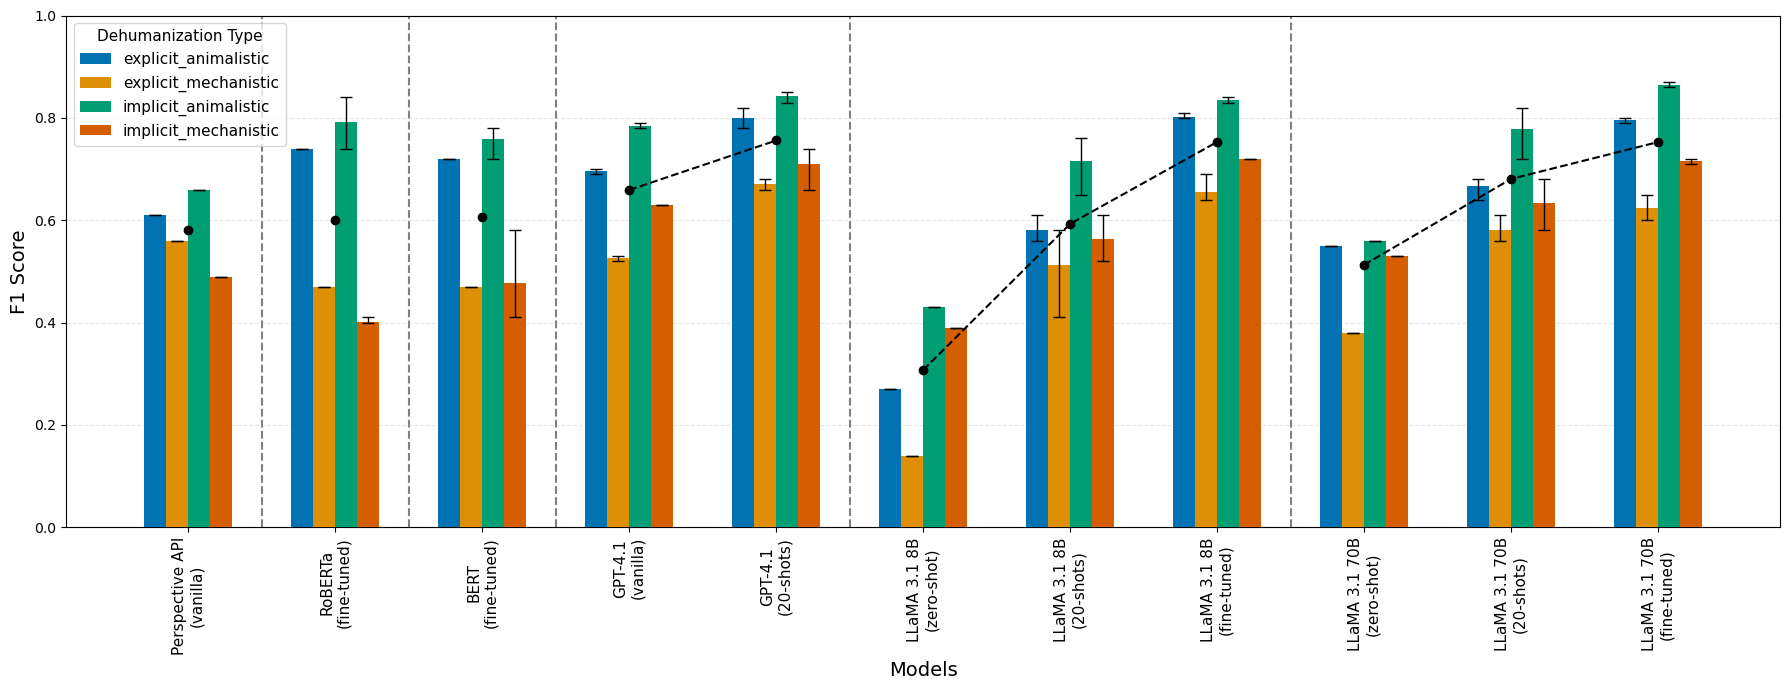

In [24]:
#import pandas as pd
#import matplotlib.pyplot as plt
#import seaborn as sns
#import numpy as np

# CSV einlesen
df = pd.read_csv("../experiments/evaluation/eval_summary_german.csv")

# Gruppierung und Variantenlogik anpassen
def extract_group_variant(model):
    if model.startswith("Llama-3.1-8B-Instruct"):
        variant = model.replace("Llama-3.1-8B-Instruct_", "").replace("fine_tuned", "fine-tuned").replace("20_shots", "20-shots").replace("zero_shot", "zero-shot")
        return "LLaMA 3.1 8B", variant
    elif model.startswith("Llama-3.1-70B-Instruct"):
        variant = model.replace("Llama-3.1-70B-Instruct_", "").replace("fine_tuned", "fine-tuned").replace("20_shots", "20-shots").replace("zero_shot", "zero-shot")
        return "LLaMA 3.1 70B", variant
    elif model.startswith("gpt4_"):
        return "GPT-4.1", model.replace("gpt4_", "").replace("20_shots", "20-shots")
    elif model == "gpt4":
        return "GPT-4.1", "vanilla"
    elif model.startswith("perspective_api"):
        return "Perspective API", "vanilla"
    elif model.endswith("_vanilla"):
        base = model.replace("_vanilla", "")
        return base if base != "bert" else "BERT", "vanilla"
    elif model in ["RoBERTa", "BERT", "HateBERT", "MetaHateBERT"]:
        return model, "fine-tuned"
    else:
        return model, "unknown"

# Spalten ergänzen
df['Model Group'], df['Variant'] = zip(*df['model'].map(extract_group_variant))
df['x_label'] = df['Model Group'] + '\n(' + df['Variant'] + ')'

# Sortierlogik
capability_order = [
    "Perspective API",
    "RoBERTa",
    "BERT",
    "HateBERT",
    "MetaHateBERT",
    "GPT-4.1",
    "LLaMA 3.1 8B",
    "LLaMA 3.1 70B"
]

variant_order = ["vanilla", "zero-shot", "20-shots", "fine-tuned"]

df['Capability Rank'] = df['Model Group'].apply(lambda x: capability_order.index(x) if x in capability_order else len(capability_order))
df['Variant Rank'] = df['Variant'].apply(lambda x: variant_order.index(x) if x in variant_order else len(variant_order))

# Aggregation
agg_df = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_type']).agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

# Sortierung der Achsenlabels
df['x_label'] = pd.Categorical(df['x_label'], categories=sorted(df['x_label'].unique(), key=lambda x: (
    capability_order.index(x.split('\n')[0]) if x.split('\n')[0] in capability_order else len(capability_order),
    variant_order.index(x.split('\n')[1].replace("(", "").replace(")", "")) if x.split('\n')[1].replace("(", "").replace(")", "") in variant_order else len(variant_order)
)), ordered=True)

agg_df['x_label'] = pd.Categorical(agg_df['x_label'], categories=df['x_label'].cat.categories, ordered=True)
agg_df = agg_df.sort_values('x_label')

# Farbpalette nach gewünschter Reihenfolge
category_order = [
    "explicit_animalistic",
    "explicit_mechanistic",
    "implicit_animalistic",
    "implicit_mechanistic"
]
palette = sns.color_palette("colorblind", len(category_order))
category_colors = dict(zip(category_order, palette))

# Positionen vorbereiten
unique_labels = list(agg_df['x_label'].cat.categories)
x_pos = np.arange(len(unique_labels))
width = 0.15

# Plot erstellen
fig, ax = plt.subplots(figsize=(18, 7))

# Balken + Whisker
for idx, cat in enumerate(category_order):
    subset = agg_df[agg_df['dehum_type'] == cat]
    indices = [unique_labels.index(lbl) for lbl in subset['x_label']]
    offsets = [i + (idx - len(category_order)/2)*width + width/2 for i in indices]
    means = subset['mean'].values
    lower_errors = np.abs(means - subset['min'].values)
    upper_errors = np.abs(subset['max'].values - means)

    yerr = np.vstack([lower_errors, upper_errors])
    ax.bar(offsets, means, width=width, color=category_colors[cat], label=cat, zorder=3)
    #ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)
    try:
        ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)
    except:
        print(f"Error for category {cat}")
        print(yerr)
        print(means)
        print(offsets)
        print(subset['min'].values)
        print(subset['max'].values)
# Vertikale Trennlinien zwischen Modellgruppen
group_boundaries = []
prev_group = None
for i, label in enumerate(unique_labels):
    group = label.split('\n')[0]
    if prev_group is not None and group != prev_group:
        group_boundaries.append(i - 0.5)
    prev_group = group

for boundary in group_boundaries:
    ax.axvline(boundary, color='grey', linestyle='--', zorder=1)

# Mittelwert-Linien pro Modellgruppe
for group in df['Model Group'].unique():
    group_df = df[df['Model Group'] == group]
    variants = group_df['x_label'].unique()
    if len(variants) == 0:
        continue
    indices = [unique_labels.index(lbl) for lbl in variants]
    means = [df[df['x_label'] == lbl]['f1'].mean() for lbl in variants]
    ax.plot(indices, means, linestyle='--', color='black', marker='o', zorder=5)

# Achsenbeschriftung und Layout
ax.set_xticks(range(len(unique_labels)))
ax.set_xticklabels(unique_labels, rotation=90, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=14)
ax.set_xlabel("Models", fontsize=14)
ax.set_ylim(0, 1)
#ax.set_title("F1 Scores grouped by Model Type and Variant", fontsize=16)
ax.legend(title="Dehumanization Type", fontsize=11, title_fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
#plt.savefig("german_f1_scores_grouped_fixed.png", dpi=300, transparent=True)
plt.show()

In [25]:
df_german = df
## mean model increase
df_german.groupby('model').agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()


,model,mean,min,max
0,BERT,0.606500,0.41,0.78
1,Llama-3.1-70B-Instruct_20_shots,0.680714,0.56,0.82
2,Llama-3.1-70B-Instruct_fine_tuned,0.752727,0.60,0.87
3,Llama-3.1-70B-Instruct_zero_shot,0.512857,0.38,0.56
4,Llama-3.1-8B-Instruct_20_shots,0.593000,0.41,0.76
5,Llama-3.1-8B-Instruct_fine_tuned,0.753000,0.64,0.84
6,Llama-3.1-8B-Instruct_zero_shot,0.307500,0.14,0.43
7,RoBERTa,0.601000,0.40,0.84
8,gpt4,0.659167,0.52,0.79
9,gpt4_20_shots,0.755833,0.66,0.85


In [26]:
df_german

,model,dehum_type,run,prec,rec,f1,lang,Model Group,Variant,x_label,Capability Rank,Variant Rank
0,BERT,explicit_animalistic,1,0.56,0.58,0.72,de,BERT,fine-tuned,BERT\n(fine-tuned),2,3
1,BERT,explicit_animalistic,2,0.56,0.58,0.72,de,BERT,fine-tuned,BERT\n(fine-tuned),2,3
2,BERT,explicit_animalistic,3,0.56,0.58,0.72,de,BERT,fine-tuned,BERT\n(fine-tuned),2,3
3,BERT,explicit_animalistic,4,0.56,0.58,0.72,de,BERT,fine-tuned,BERT\n(fine-tuned),2,3
4,BERT,explicit_animalistic,5,0.56,0.58,0.72,de,BERT,fine-tuned,BERT\n(fine-tuned),2,3
...,...,...,...,...,...,...,...,...,...,...,...,...
162,gpt4,implicit_animalistic,3,0.78,0.94,0.79,de,GPT-4.1,vanilla,GPT-4.1\n(vanilla),5,0
163,gpt4_20_shots,implicit_animalistic,1,0.85,0.89,0.83,de,GPT-4.1,20-shots,GPT-4.1\n(20-shots),5,2
164,gpt4_20_shots,implicit_animalistic,2,0.89,0.87,0.85,de,GPT-4.1,20-shots,GPT-4.1\n(20-shots),5,2
165,gpt4_20_shots,implicit_animalistic,3,0.88,0.86,0.85,de,GPT-4.1,20-shots,GPT-4.1\n(20-shots),5,2


In [27]:
df_german.groupby('dehum_type').agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

,dehum_type,mean,min,max
0,explicit_animalistic,0.651220,0.27,0.82
1,explicit_mechanistic,0.491220,0.14,0.69
2,implicit_animalistic,0.721556,0.43,0.87
3,implicit_mechanistic,0.555000,0.39,0.74


In [28]:
## mean model increase
df_eng.groupby('model').agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()


,model,mean,min,max
0,BERT,0.657000,0.39,0.78
1,HateBERT,0.743000,0.70,0.80
2,HateBERT_vanilla,0.507500,0.38,0.56
3,Llama-3.1-70B-Instruct_20_shots,0.682727,0.61,0.72
4,Llama-3.1-70B-Instruct_fine_tuned,0.774167,0.72,0.82
5,Llama-3.1-70B-Instruct_zero_shot,0.644375,0.54,0.69
6,Llama-3.1-8B-Instruct_20_shots,0.634500,0.50,0.71
7,Llama-3.1-8B-Instruct_fine_tuned,0.762000,0.70,0.82
8,Llama-3.1-8B-Instruct_zero_shot,0.512500,0.43,0.55
9,MetaHateBERT,0.689000,0.61,0.79


In [29]:
## metahatebart
old = 0.58
new = 0.69
(new - old) / old * 100



18.96551724137931

In [30]:
## 8b english from zero to fine-tuning
old = 0.51
new = 0.76
first = (new - old) / old * 100

old = 0.64
new = 0.77
second = (new - old) / old * 100


## 8b german
old = 0.307
new = 0.753
third = (new - old) / old * 100

old = 0.51
new = 0.75
fourth = (new - old) / old * 100


##average first and second
(first + second + third + fourth) / 4


65.4169510841796

In [31]:
## 8b english from zero to few-shot
old = 0.51
new = 0.634
first = (new - old) / old * 100

old = 0.64
new = 0.682
second = (new - old) / old * 100


## 8b german
old = 0.307
new = 0.59
third = (new - old) / old * 100

old = 0.51
new = 0.680
fourth = (new - old) / old * 100


##average first and second
(first + second + third + fourth) / 4


39.09799231174555

/var/folders/8l/cjyv75b11sl8w9_pt4rvl4v40000gn/T/ipykernel_45642/1263827382.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_anim = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_animMech']).agg(


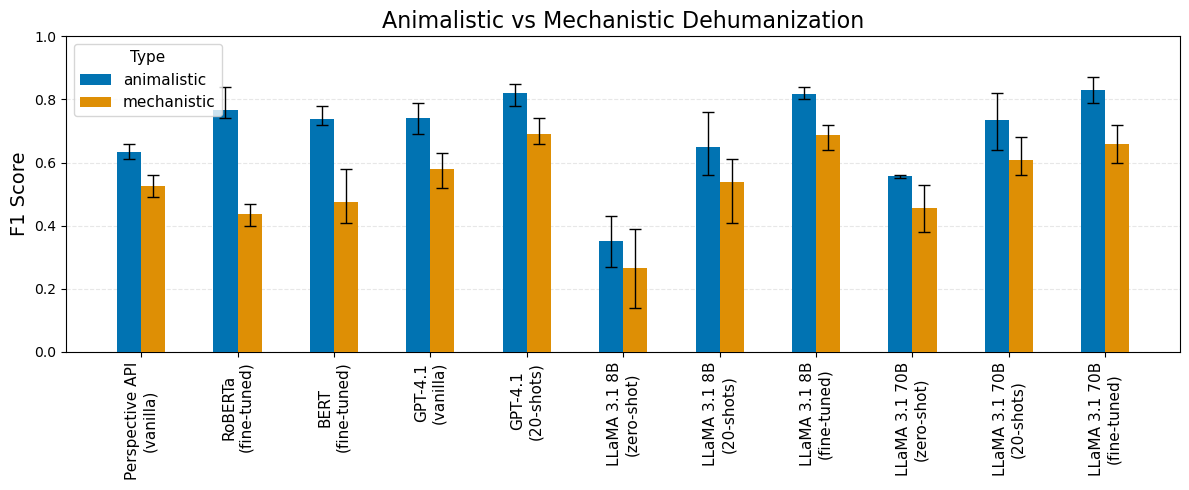

In [32]:
# ===============================
# 1) ANIMALISTIC vs MECHANISTIC
# ===============================

df['dehum_group_animMech'] = df['dehum_type'].map({
    'explicit_animalistic': 'animalistic',
    'implicit_animalistic': 'animalistic',
    'explicit_mechanistic': 'mechanistic',
    'implicit_mechanistic': 'mechanistic'
})

agg_anim = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_animMech']).agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

category_order_anim = ["animalistic", "mechanistic"]
palette_anim = sns.color_palette("colorblind", len(category_order_anim))
category_colors_anim = dict(zip(category_order_anim, palette_anim))

fig, ax = plt.subplots(figsize=(12, 5))
unique_labels = list(df['x_label'].cat.categories)
x_pos = np.arange(len(unique_labels))
width = 0.25

for idx, cat in enumerate(category_order_anim):
    subset = agg_anim[agg_anim['dehum_group_animMech'] == cat]
    indices = [unique_labels.index(lbl) for lbl in subset['x_label']]
    offsets = [i + (idx - len(category_order_anim)/2)*width + width/2 for i in indices]
    means = subset['mean'].values
    yerr = [means - subset['min'].values, subset['max'].values - means]

    ax.bar(offsets, means, width=width, color=category_colors_anim[cat], label=cat, zorder=3)
    ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)

ax.set_xticks(range(len(unique_labels)))
ax.set_xticklabels(unique_labels, rotation=90, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=14)
#ax.set_xlabel("Models", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title("Animalistic vs Mechanistic Dehumanization", fontsize=16)
ax.legend(title="Type", fontsize=11, title_fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
#plt.savefig("f1_anim_vs_mech_geman.pdf", dpi=300, transparent=True)
plt.show()

/var/folders/8l/cjyv75b11sl8w9_pt4rvl4v40000gn/T/ipykernel_45642/1323733136.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_expimp = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_expImp']).agg(


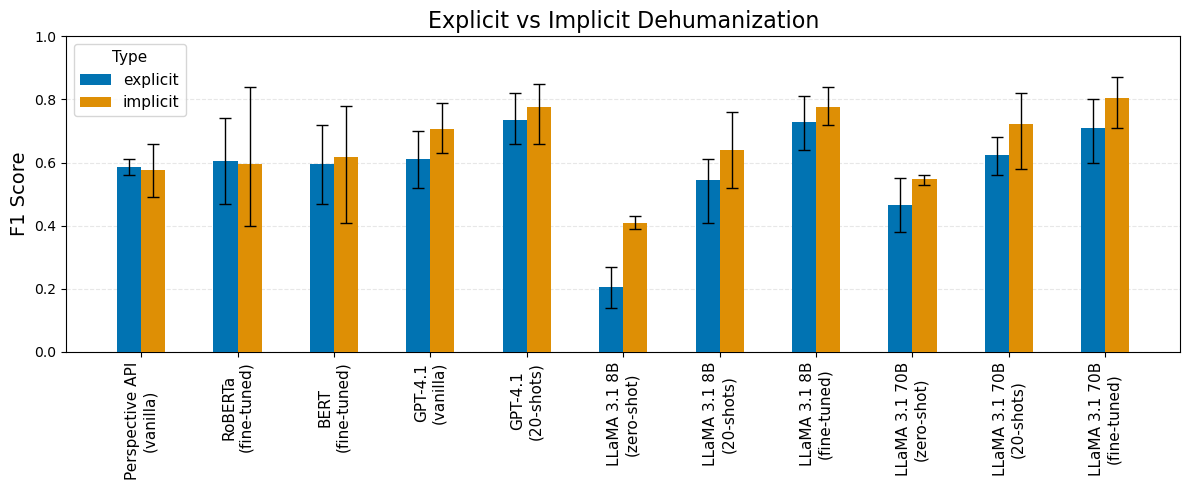

In [33]:
# ===============================
# 2) EXPLICIT vs IMPLICIT
# ===============================

df['dehum_group_expImp'] = df['dehum_type'].map({
    'explicit_animalistic': 'explicit',
    'explicit_mechanistic': 'explicit',
    'implicit_animalistic': 'implicit',
    'implicit_mechanistic': 'implicit'
})

agg_expimp = df.groupby(['x_label', 'Model Group', 'Variant', 'dehum_group_expImp']).agg(
    mean=('f1', 'mean'),
    min=('f1', 'min'),
    max=('f1', 'max')
).reset_index()

category_order_expimp = ["explicit", "implicit"]
palette_expimp = sns.color_palette("colorblind", len(category_order_expimp))
category_colors_expimp = dict(zip(category_order_expimp, palette_expimp))

fig, ax = plt.subplots(figsize=(12, 5))
unique_labels = list(df['x_label'].cat.categories)
x_pos = np.arange(len(unique_labels))
width = 0.25

for idx, cat in enumerate(category_order_expimp):
    subset = agg_expimp[agg_expimp['dehum_group_expImp'] == cat]
    indices = [unique_labels.index(lbl) for lbl in subset['x_label']]
    offsets = [i + (idx - len(category_order_expimp)/2)*width + width/2 for i in indices]
    means = subset['mean'].values
    yerr = [means - subset['min'].values, subset['max'].values - means]

    ax.bar(offsets, means, width=width, color=category_colors_expimp[cat], label=cat, zorder=3)
    ax.errorbar(offsets, means, yerr=yerr, fmt='none', ecolor='black', capsize=4, lw=1, zorder=4)

ax.set_xticks(range(len(unique_labels)))
ax.set_xticklabels(unique_labels, rotation=90, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=14)
#ax.set_xlabel("Models", fontsize=14)
ax.set_ylim(0, 1)
ax.set_title("Explicit vs Implicit Dehumanization", fontsize=16)
ax.legend(title="Type", fontsize=11, title_fontsize=11)
ax.grid(True, axis='y', linestyle='--', alpha=0.3, zorder=0)

plt.tight_layout()
#plt.savefig("f1_explicit_vs_implicit_german.pdf", dpi=300, transparent=True)
plt.show()

/var/folders/8l/cjyv75b11sl8w9_pt4rvl4v40000gn/T/ipykernel_45642/3802885545.py:76: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  agg_df = df.groupby(["x_label", "dehum_type", "type"]).agg(


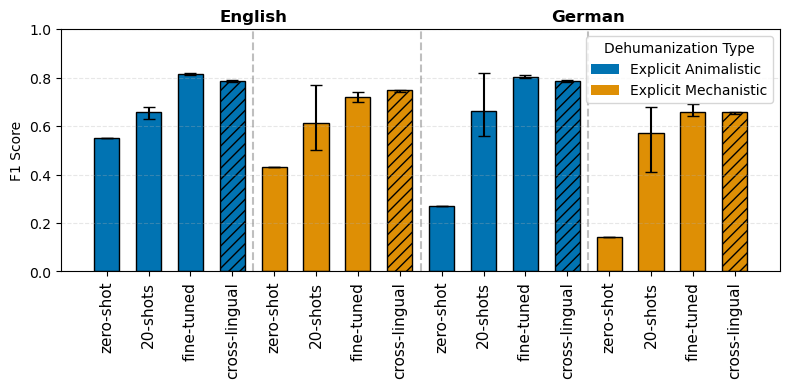

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Daten laden
df = pd.read_csv("../experiments/evaluation/crosseval_eval_summary.csv")

# 2. Modellvariante extrahieren
def extract_variant(model):
    if "zero_shot" in model:
        return "zero-shot"
    elif "20_shots" in model:
        return "20-shots"
    elif "fine_tuned" in model:
        return "fine-tuned"
    else:
        return "vanilla"

df["variant"] = df["model"].apply(extract_variant)

# 3. Zielgruppe bestimmen
def determine_group(row):
    base = f"{row['lang']} | {row['dehum_type']}"
    if row["type"] == "cross-lingual":
        return base + " | cross-lingual"
    else:
        return base + " | direct"

df["group"] = df.apply(determine_group, axis=1)

# 4. Ungültige Kombinationen entfernen
df = df[~((df["type"] == "cross-lingual") & (df["variant"] != "fine-tuned"))]

# 5. X-Achsenbeschriftungen
def make_x_label(row):
    variant = "cross-lingual" if row["type"] == "cross-lingual" else row["variant"]
    return row["group"] + "\n" + variant

df["x_label"] = df.apply(make_x_label, axis=1)

# 6. Reihenfolge definieren
group_order = [
    "en | explicit_animalistic | direct",
    "en | explicit_animalistic | cross-lingual",
    "en | explicit_mechanistic | direct",
    "en | explicit_mechanistic | cross-lingual",
    "de | explicit_animalistic | direct",
    "de | explicit_animalistic | cross-lingual",
    "de | explicit_mechanistic | direct",
    "de | explicit_mechanistic | cross-lingual"
]

variant_order = ["zero-shot", "20-shots", "fine-tuned", "cross-lingual"]

x_label_order = []
x_label_clean = {}

for group in group_order:
    for variant in variant_order:
        if "cross-lingual" in group and variant != "cross-lingual":
            continue
        if "direct" in group and variant == "cross-lingual":
            continue
        full_label = f"{group}\n{variant}"

        # statt Sprache + variant nur variant anzeigen
        clean = variant  

        x_label_order.append(full_label)
        x_label_clean[full_label] = clean

df["x_label"] = pd.Categorical(df["x_label"], categories=x_label_order, ordered=True)

# 7. Aggregation mit 'type' zur Schraffierung
agg_df = df.groupby(["x_label", "dehum_type", "type"]).agg(
    mean_f1=("f1", "mean"),
    min_f1=("f1", "min"),
    max_f1=("f1", "max")
).reset_index()

# 8. Farben
palette = sns.color_palette("colorblind", n_colors=2)
category_colors = dict(zip(["explicit_animalistic", "explicit_mechanistic"], palette))

# 9. Plot vorbereiten
fig, ax = plt.subplots(figsize=(8, 4))
x_pos = np.arange(len(x_label_order))
width = 0.6

for dehum_type in ["explicit_animalistic", "explicit_mechanistic"]:
    subset = agg_df[agg_df["dehum_type"] == dehum_type]
    for i, row in subset.iterrows():
        x = x_label_order.index(row["x_label"])
        y = row["mean_f1"]
        yerr = [[y - row["min_f1"]], [row["max_f1"] - y]]
        hatch = "///" if row["type"] == "cross-lingual" else None

        bar = ax.bar(x, y, width=width, color=category_colors[dehum_type],
                     hatch=hatch, edgecolor='black', label=None if hatch else dehum_type)
        ax.errorbar(x, y, yerr=np.array(yerr), fmt='none', ecolor='black', capsize=4)

# 10. Achsen und Legende (angepasst)
ax.set_xticks(x_pos)
ax.set_xticklabels([x_label_clean[label] for label in x_label_order],
                   rotation=90, ha="center", fontsize=11)

ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1)

from matplotlib.patches import Patch
handles = [
    Patch(facecolor=category_colors["explicit_animalistic"], label="Explicit Animalistic"),
    Patch(facecolor=category_colors["explicit_mechanistic"], label="Explicit Mechanistic"),
]
ax.legend(handles=handles, title="Dehumanization Type", fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.3)

# 11. Vertikale Trennlinien
group_counts = {
    "en | explicit_animalistic": 4,
    "en | explicit_mechanistic": 4,
    "de | explicit_animalistic": 4,
    "de | explicit_mechanistic": 4
}

boundary_positions = []
count = 0
for group in group_counts.values():
    count += group
    boundary_positions.append(count - 0.5)

for pos in boundary_positions[:-1]:
    ax.axvline(x=pos, color="grey", linestyle="--", alpha=0.5)

# 11b. Sprachlabels zentriert oben drüber
# Positionen der Blöcke: je 8 Balken für English, 8 für German
mid_english = (0 + 7) / 2   # Mitte von 8 Balken (0–7)
mid_german = (8 + 15) / 2   # Mitte von 8 Balken (8–15)

ax.text(mid_english, 1.02, "English", ha="center", va="bottom", 
        fontsize=12, fontweight="bold", transform=ax.get_xaxis_transform())
ax.text(mid_german, 1.02, "German", ha="center", va="bottom", 
        fontsize=12, fontweight="bold", transform=ax.get_xaxis_transform())

# 12. Export
plt.tight_layout()
#plt.savefig("llama_cross_eval_hatched.pdf", dpi=300, transparent=True)
plt.show()